# Mathematical Engineering - Financial Engineering, FY 2025-2026
# Risk Management - Exercise 5: Extended Vasiceck model Monte Carlo simulation for CCR estimation

#### Import the libraries and functions needed created in previous labs

In [69]:
# Importing the libraries
import os
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import datetime


from utilities.date_functions import (
    business_date_offset,
    date_series,
    year_frac_act_x,
    year_frac_30e_360
)

from utilities.ex0_utilities import (
    bootstrap,
    from_discount_factors_to_zero_rates,
    get_discount_factor_by_zero_rates_linear_interp)

from utilities.ex1_utilities import (
    swap_par_rate,
    SwapType
)

from utilities.ex5_utilities import (
    simulate_ou_process,
    affine_trick,
    update_collateral
)


#### Bootstrap 

In [70]:
# Import here the market data and run your bootstrap function

data_path = Path(r"C:\\Users\\fabar\\OneDrive\\Desktop\\AssignmentsFINENG\\Assignment5_Group2RM\\data")

settlement_date  = datetime(2008,2,19)


depo_converter = lambda x: float(x) / 100.0  

# Ingest Money Market Deposit rates and apply unit normalization
df_depos = pd.read_csv(data_path/'depos.csv', 
                    index_col='Depos',
                    usecols=['Depos', 'ASK', 'BID'], 
                    converters={'Depos': pd.to_datetime, 'BID': depo_converter, 'ASK': depo_converter})

# Convert Future price quotes into implied forward rates (100 - Price) / 100
future_converter = lambda x: (100 - float(x)) / 100 

futures = pd.read_csv(data_path/'futures.csv',
                    index_col='Futures',
                    usecols=['Futures', 'ASK', 'BID'],
                    converters={'Futures': pd.to_datetime, 'BID': future_converter, 'ASK': future_converter})

# Load contract specifications (Settle/Expiry) and merge with price data
expiry = pd.read_csv(data_path/'expiry.csv',
                    index_col='Futures',
                    usecols=['Futures', 'Settle', 'Expiry'], 
                    converters={'Futures': pd.to_datetime, 'Settle': pd.to_datetime, 'Expiry': pd.to_datetime})
df_futures = futures.join(expiry)

# Standardize Interest Rate Swap (IRS) quotes
swap_converter = lambda x: float(x) / 100 

df_swaps = pd.read_csv(data_path/'swaps.csv',
                    index_col='Swaps',
                    usecols=['Swaps', 'BID', 'ASK'],
                    converters={'Swaps': pd.to_datetime, 'BID': swap_converter, 'ASK': swap_converter})

In [71]:
discount_factors, zero_rates, dates = bootstrap(settlement_date, df_depos, df_futures, df_swaps, depo_idx=[0, 3], fut_idx=[0, 7])

#### MonteCarlo grid set up

In [72]:
# Monte Carlo Simulations parameters, grids and outputs to store

# params
np.random.seed(11)
simulations_num = 250_000
years_to_simulate = 10

# last point on the simulation grid
simulations_expiry = business_date_offset(settlement_date, year_offset=years_to_simulate) 

# 40 simulation dates (t_0 non a simulation date)
total_point = 40
point_per_year = total_point//years_to_simulate
simulation_grid = date_series(settlement_date, simulations_expiry, point_per_year)[1:]


# output to compute
expected_positive_exposure = pd.DataFrame(
    data=0.0, index=simulation_grid, columns=["base", "break", "no netting", "netting", "collateral"])

alpha = 0.95
potential_future_exposure = pd.DataFrame(
    data=0.0, index=simulation_grid, columns=["base", "break", "no netting", "netting", "collateral"]
)

#### Set up of the base contract

In [73]:
####### 10 y payer swap #######

# Parameters for the 10y payer swap
notional = 100_000_000
swap_type = SwapType.PAYER
maturity = 10
fixed_freq = 1  # annual

# Expiry date: settlement + 10 years (closest following business day)
expiry = business_date_offset(settlement_date, year_offset=maturity)

# Fixed-leg payment schedule: dates from settlement to expiry at annual frequency
# date_series returns t_0, t_1, ..., t_N (N+1 dates, so 11 for a 10y annual swap)
fixed_leg_payment_dates = date_series(settlement_date, expiry, fixed_freq)[1:]  # exclude t_0, only payment dates

# Assume swap traded at par: the fixed rate is the par swap rate computed from today's curve
swap_rate = swap_par_rate(
    fixed_leg_schedule=fixed_leg_payment_dates,   # exclude t_0, only payment dates
    discount_factors=discount_factors
)

# Fixed-leg cash flows: at each payment date t_i, the holder pays/receives K * delta_i
# where delta_i is the 30E/360 year fraction between t_{i-1} and t_i
all_dates = [settlement_date] + fixed_leg_payment_dates

irs_cash_flows = pd.Series(
    data=[
        swap_rate * year_frac_30e_360(all_dates[i-1], all_dates[i])
        for i in range(1, len(all_dates))
    ],
    index=fixed_leg_payment_dates
)

# Reindex on the simulation grid: cash flows fall on grid dates if 4 points/year and
# annual payments are aligned. Non-payment grid dates get 0.0.
irs_cash_flows_extended = (
    irs_cash_flows
    .reindex(simulation_grid, fill_value=0.0)
)



#### Set up of the alternative scenarios 

In [74]:
# a) mandatory break clause
# Set up of the break date
break_year = 3
break_month = 6

# Break date: settlement + 3y6m, mod-following business day adjustment handled by helper
break_expiry = business_date_offset(
    settlement_date, year_offset=break_year, month_offset=break_month
)


# b) 5 y receiver swap
# Parameters for the 5y receiver swap
# swap 2 has fixed leg quarterly, float leg quarterly (euribor 3m), same yf conventions of base swap
notional_2 = 150_000_000
swap_type_2 = SwapType.RECEIVER
maturity_2 = 5
fixed_freq_2 = 4 

# !!! COMPLETE AS APPROPRIATE !!!
expiry_2 = business_date_offset(
    settlement_date, year_offset=maturity_2, month_offset=0
)
fixed_leg_payment_dates_2 = date_series(settlement_date, expiry_2, fixed_freq_2)[1:]  # 20 dates, t_0 excluded

# assume swap traded at par
swap_rate_2 = swap_par_rate(
    fixed_leg_schedule=fixed_leg_payment_dates_2,
    discount_factors=discount_factors
)

# Fixed-leg cash flows: K * delta_i with delta_i = 30E/360 yf between consecutive payment dates
all_dates_2 = [settlement_date] + fixed_leg_payment_dates_2

irs_cash_flows_2 = pd.Series(
    data=[
        swap_rate_2 * year_frac_30e_360(all_dates_2[i-1], all_dates_2[i])
        for i in range(1, len(all_dates_2))
    ],
    index=fixed_leg_payment_dates_2
)


# fixed leg cash flows extended on simulation grid
irs_cash_flows_extended_2 = (
    irs_cash_flows_2
    .reindex(simulation_grid, fill_value=0.0)
)


# c) CSA agreement
# No IA, no rounding, no haircut, no delay in the posting of the collateral (i.e. margin call done at t -> new collateral posted at t)
# CSA parameters for party B (Polimi Bank)

# !!! COMPLETE AS APPROPRIATE !!!
THR_B = np.inf
MTA_B = np.inf   # given, choose correctly the other parameters
Cap_B = 0 # given, choose correctly the other parameters

THR_C = 0
MTA_C = 0      # given, choose correctly the other parameters
Cap_C = np.inf

#### x_t OU Process simulations

In [75]:
# OU process parameters
mean_reversion = 0.0205
sigma = 0.0094

x_paths = simulate_ou_process(simulation_grid,
                              settlement_date, 
                              mean_reversion, 
                              sigma, 
                              simulations_num,
                              x0=0)

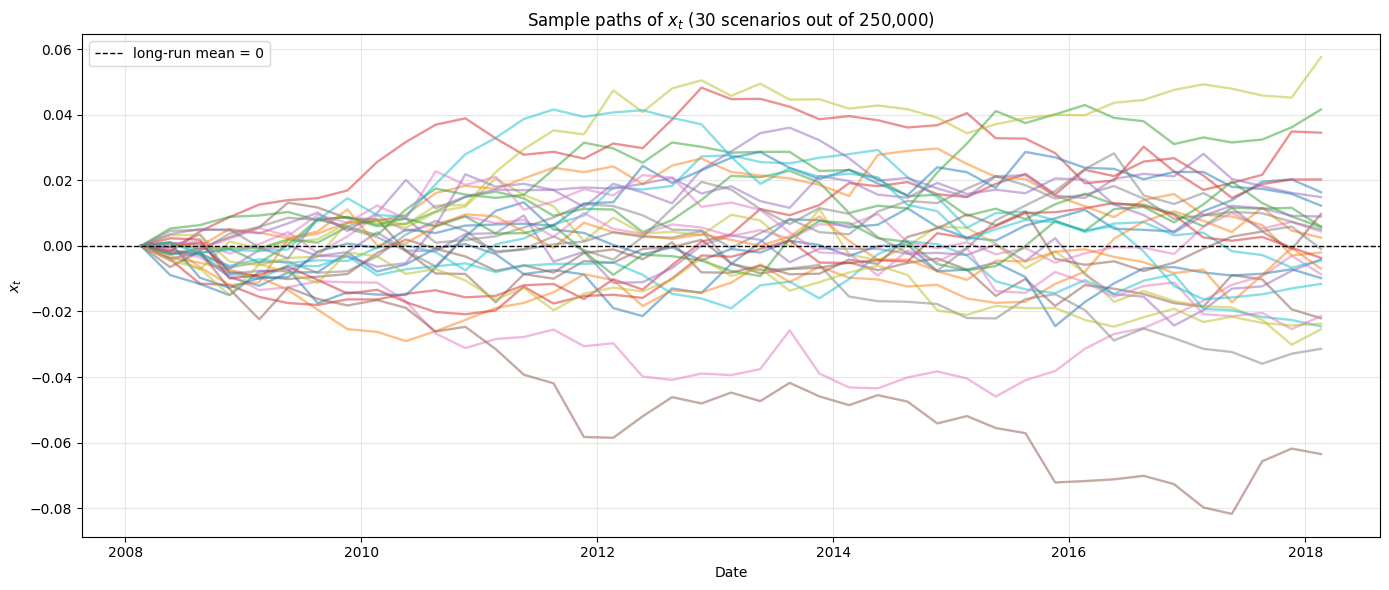

In [76]:
# Add t_0 at the start (at t_0, x_0 = 0 in all simulations)
plot_dates = [settlement_date] + list(simulation_grid)
plot_paths = np.column_stack([np.zeros(simulations_num), x_paths])

# Pick a few random scenarios to visualise
n_plot = 30
idx = np.random.choice(simulations_num, size=n_plot, replace=False)

plt.figure(figsize=(14, 6))
for j in idx:
    plt.plot(plot_dates, plot_paths[j, :], alpha=0.5, linewidth=1.7)

plt.axhline(0, color='black', linestyle='--', linewidth=1, label='long-run mean = 0')
plt.title(f"Sample paths of $x_t$ ({n_plot} scenarios out of {simulations_num:,})")
plt.xlabel("Date")
plt.ylabel(r"$x_t$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### From OU to discount factors and MtM and exposures

In [77]:

# Initialization of zero rates: ensure the first simulation date is in the index
zero_rates = (
    zero_rates.reindex(zero_rates.index.union([simulation_grid[0]]))
    .sort_index()
    .interpolate(method="index")
)

# Initialization of collateral, risk-free rate and last margin call date
collateral_posted = np.zeros(simulations_num)
risk_free_rate = np.full(simulations_num, zero_rates.loc[simulation_grid[0]])
last_collateral_posting_date = settlement_date

prev_date = settlement_date

for i, sim_date in enumerate(simulation_grid):

    expiry_idx1 = list(simulation_grid[i:]).index(expiry) if expiry in simulation_grid[i:] else None
    expiry_idx2 = list(simulation_grid[i:]).index(expiry_2) if expiry_2 in simulation_grid[i:] else None

    dt = year_frac_act_x(prev_date, sim_date, 365)

    # -----------------------------------------------------------------------
    # STEP 1: market simulation at sim_date
    # -----------------------------------------------------------------------

    # State variable x_t for all scenarios at this simulation date
    x_t = x_paths[:, i]                                          # shape (n_sim,)

    # A(s, T) and C(s, T): deterministic, shared across all scenarios
    A, C = affine_trick(sim_date, simulation_grid[i:], mean_reversion, sigma, discount_factors)

    # Discount factors B(s, t_j) for each t_j in simulation_grid, for each scenario
    # Broadcasting: (1, n_grid) * exp(-(n_sim, 1) * (1, n_grid)) -> (n_sim, n_grid)
    discount_factors_hw = (
        A.values[np.newaxis, :]
        * np.exp(-C.values[np.newaxis, :] * x_t[:, np.newaxis])
    )                                                             # shape (n_sim, n_grid)

    # -----------------------------------------------------------------------
    # STEP 2: MtM of swap 1 (10y payer)
    # float leg = 1 - B(s, t_N), fixed leg = sum of discounted cash flows
    # payer MtM = float leg - fixed leg
    # -----------------------------------------------------------------------

    # Fixed leg PV: sum over future payment dates of K*delta_j * B(s, t_j)
    fixed_leg_1 = (
        irs_cash_flows_extended.values[np.newaxis, i:] * discount_factors_hw
    ).sum(axis=1)                                                 # shape (n_sim,)

    if expiry_idx1 is not None:
        float_leg_1 = 1.0 - discount_factors_hw[:, expiry_idx1]
        MtF_1 = notional * (float_leg_1 - fixed_leg_1)
    else:
        MtF_1 = np.zeros(simulations_num)   # swap 1 expired

    # -----------------------------------------------------------------------
    # STEP 3: MtM of swap 2 (5y receiver) — needed for netting scenario
    # receiver MtM = - (float leg - fixed leg) = fixed - float
    # -----------------------------------------------------------------------

    if expiry_idx2 is not None and sim_date <= expiry_2:

        fixed_leg_2 = (
            irs_cash_flows_extended_2.values[np.newaxis, i:] * discount_factors_hw
        ).sum(axis=1)                                             # shape (n_sim,)

        
        float_leg_2 = 1.0 - discount_factors_hw[:, expiry_idx2] # shape (n_sim,)

        if swap_type_2 == SwapType.RECEIVER:
            MtF_2 = notional_2 * (fixed_leg_2 - float_leg_2)        # shape (n_sim,)
        else: 
            MtF_2 = notional_2 * (float_leg_2 - fixed_leg_2)        # shape (n_sim,)
    else:
        # Swap 2 has expired: no more exposure
        MtF_2 = np.zeros(simulations_num)

    # -----------------------------------------------------------------------
    # STEP 4: derive the 5 MtM profiles
    # -----------------------------------------------------------------------

    # Base case: standalone swap 1
    MtF_base = MtF_1

    # 6a: break clause — exposure is zero after the break date
    MtF_break = np.where(sim_date <= break_expiry, MtF_1, 0.0)

    # 6b netting: net MtM of the two swaps combined
    MtF_netting = MtF_1 + MtF_2

    # 6b no netting: sum of standalone positive exposures (subadditive benchmark)
    # EPE_no_netting = E[max(MtF1,0)] + E[max(MtF2,0)] — computed below

    # 6c collateral: remunerate and possibly update collateral, then net it off
    collateral_posted *= np.exp(
        risk_free_rate * dt
    )

    if (sim_date - last_collateral_posting_date).days >= 360:
        last_collateral_posting_date = sim_date                  # ← was None in skeleton: bug fixed
        collateral_posted = update_collateral(
            MtF_1, collateral_posted,
            THR_B, THR_C, MTA_B, MTA_C, Cap_B, Cap_C
        )

    MtF_coll = MtF_1 - collateral_posted                        # exposure net of CSA

    # -----------------------------------------------------------------------
    # STEP 5: positive exposures (floor at 0)
    # -----------------------------------------------------------------------

    MtF_pos_base     = np.maximum(MtF_base,     0.0)
    MtF_pos_break    = np.maximum(MtF_break,    0.0)
    MtF_pos_1        = np.maximum(MtF_1,        0.0)   # standalone swap 1
    MtF_pos_2        = np.maximum(MtF_2,        0.0)   # standalone swap 2
    MtF_pos_netting  = np.maximum(MtF_netting,  0.0)
    MtF_pos_coll     = np.maximum(MtF_coll,     0.0)

    # -----------------------------------------------------------------------
    # STEP 6: EPE = mean of positive exposure across scenarios
    # -----------------------------------------------------------------------

    expected_positive_exposure.loc[sim_date, "base"]       = MtF_pos_base.mean()
    expected_positive_exposure.loc[sim_date, "break"]      = MtF_pos_break.mean()
    expected_positive_exposure.loc[sim_date, "no netting"] = (MtF_pos_1 + MtF_pos_2).mean()
    expected_positive_exposure.loc[sim_date, "netting"]    = MtF_pos_netting.mean()
    expected_positive_exposure.loc[sim_date, "collateral"] = MtF_pos_coll.mean()

    # -----------------------------------------------------------------------
    # STEP 7: PFE = 95th quantile of positive exposure across scenarios
    # -----------------------------------------------------------------------

    potential_future_exposure.loc[sim_date, "base"]       = np.quantile(MtF_pos_base,    alpha)
    potential_future_exposure.loc[sim_date, "break"]      = np.quantile(MtF_pos_break,   alpha)
    potential_future_exposure.loc[sim_date, "no netting"] = np.quantile(MtF_pos_1 + MtF_pos_2, alpha)
    potential_future_exposure.loc[sim_date, "netting"]    = np.quantile(MtF_pos_netting, alpha)
    potential_future_exposure.loc[sim_date, "collateral"] = np.quantile(MtF_pos_coll,    alpha)

    # -----------------------------------------------------------------------
    # STEP 8: update risk-free rate for next step collateral remuneration
    # use the shortest available zero rate from the HW simulated curve
    # -----------------------------------------------------------------------

    if i < len(simulation_grid) - 1:
        # Next simulation date discount factor B(s, s_next), one per scenario
        future_dfs  = discount_factors_hw[:, 1]              # shape (n_sim,)
        year_fracs  = year_frac_act_x(sim_date, simulation_grid[i + 1], 365)

        # Zero rate = -log(DF) / yf, scenario by scenario
        risk_free_rate = -np.log(future_dfs) / year_fracs        # shape (n_sim,)

    prev_date = sim_date

#### Peak PFE

In [78]:
# Compute for each scenario the peak-PFE and the t at which it materialize
peak_pfe = pd.DataFrame(data = 0, index=["base", "break", "no netting", "netting", "collateral"], columns = ['t','Peak_PFE'])
peak_pfe['Peak_PFE'] = potential_future_exposure.max()
peak_pfe['t'] = potential_future_exposure.idxmax()

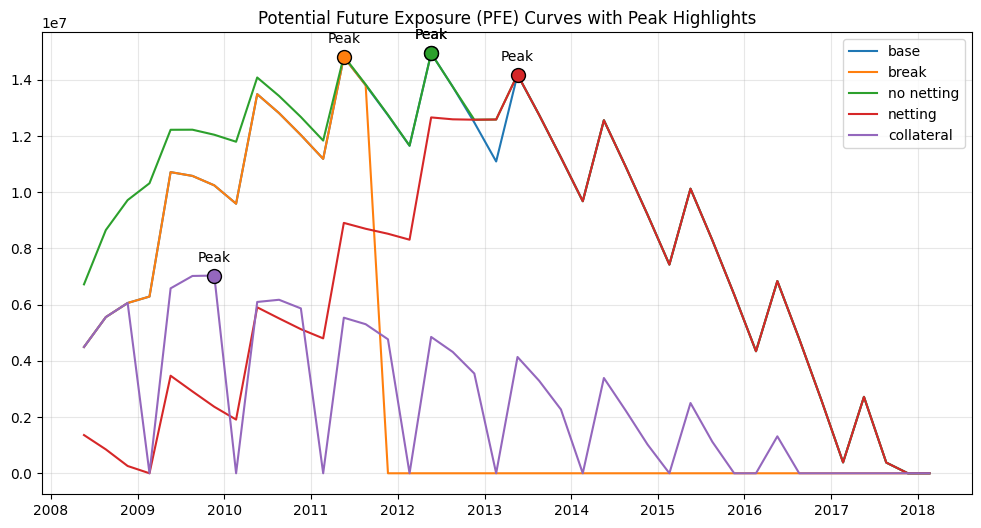

In [79]:
plt.figure(figsize=(12, 6))
for col in potential_future_exposure.columns:
    line, = plt.plot(potential_future_exposure.index, potential_future_exposure[col], label=col)
    
    t_peak = peak_pfe.loc[col, 't']
    val_peak = peak_pfe.loc[col, 'Peak_PFE']
    
    plt.scatter(t_peak, val_peak, color=line.get_color(), s=100, edgecolors='black', zorder=5)
    plt.annotate(f'Peak', (t_peak, val_peak), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Potential Future Exposure (PFE) Curves with Peak Highlights')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### PLOT 

<Figure size 1500x500 with 0 Axes>

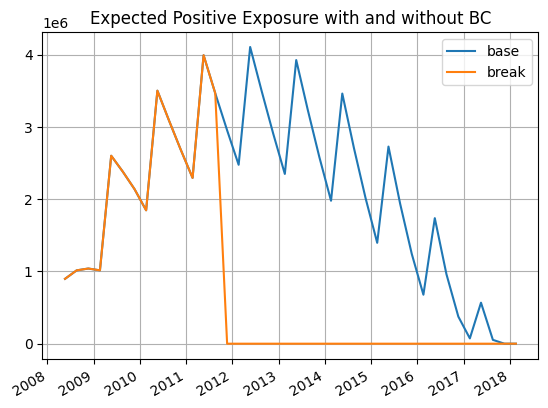

<Figure size 1500x500 with 0 Axes>

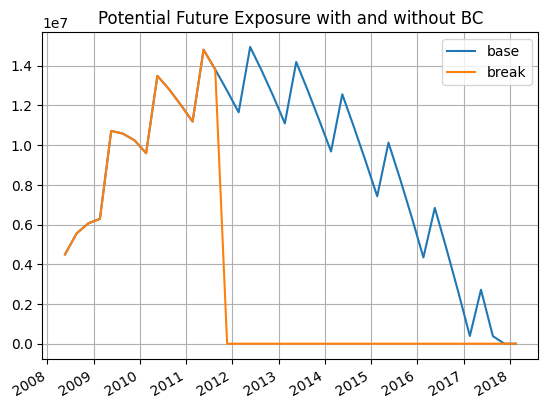

<Figure size 1500x500 with 0 Axes>

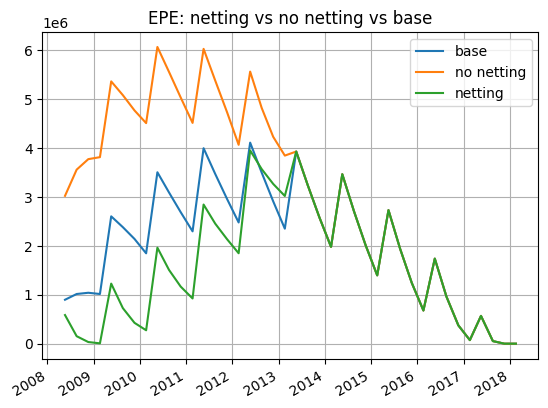

<Figure size 1500x500 with 0 Axes>

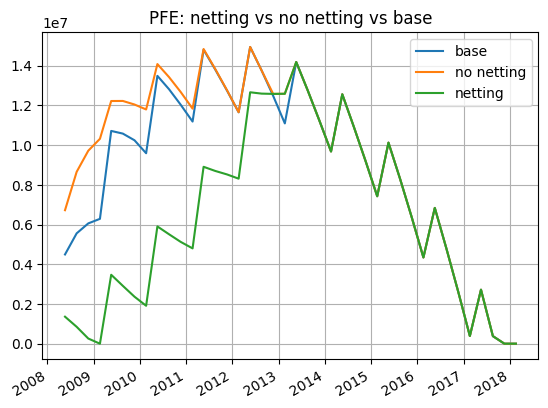

<Figure size 1500x500 with 0 Axes>

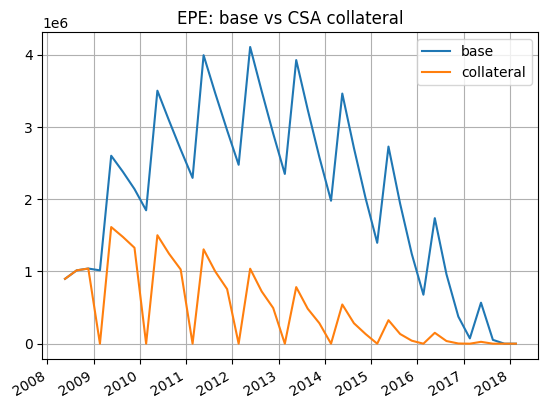

<Figure size 1500x500 with 0 Axes>

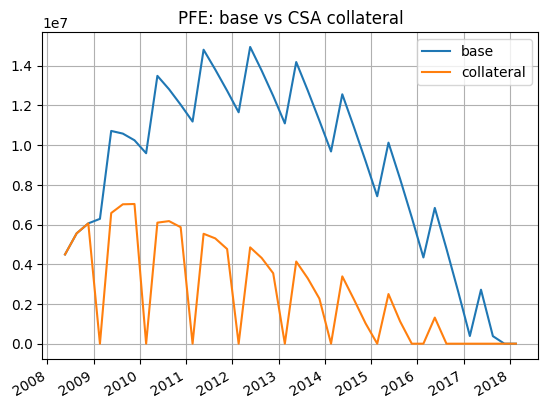

In [80]:
### plot 6 a
plt.figure(figsize=(15, 5))
expected_positive_exposure[['base','break']].plot()
plt.title(f"Expected Positive Exposure with and without BC")
plt.grid()
plt.show()

plt.figure(figsize=(15, 5))
potential_future_exposure[['base','break']].plot()
plt.title(f"Potential Future Exposure with and without BC")
plt.grid()
plt.show()

### plot 6 b
plt.figure(figsize=(15, 5))
expected_positive_exposure[['base', 'no netting', 'netting']].plot()
plt.title("EPE: netting vs no netting vs base")
plt.grid()
plt.show()

plt.figure(figsize=(15, 5))
potential_future_exposure[['base', 'no netting', 'netting']].plot()
plt.title("PFE: netting vs no netting vs base")
plt.grid()
plt.show()

### plot 6 c
plt.figure(figsize=(15, 5))
expected_positive_exposure[['base', 'collateral']].plot()
plt.title("EPE: base vs CSA collateral")
plt.grid()
plt.show()

plt.figure(figsize=(15, 5))
potential_future_exposure[['base', 'collateral']].plot()
plt.title("PFE: base vs CSA collateral")
plt.grid()
plt.show()


#### CVA estimations

In [81]:
# Parameters
hazard_rate = 0.02
lgd = 0.6

times = np.array([year_frac_act_x(settlement_date, d, 365) for d in expected_positive_exposure.index])
CVA_discount_factors = np.array([
    get_discount_factor_by_zero_rates_linear_interp(
        settlement_date, d, discount_factors.index, discount_factors.values
    ) for d in expected_positive_exposure.index
])


exp_terms = np.exp(- hazard_rate * times)
exp_terms_with_zero = np.insert(exp_terms, 0, 1.0)
delta_integral = - (exp_terms_with_zero[1:] - exp_terms_with_zero[:-1])

discounting_weights = (CVA_discount_factors * delta_integral)[:, np.newaxis]

cva_values = lgd * np.sum(expected_positive_exposure.values * discounting_weights, axis=0)

CVA_results = pd.Series(cva_values, index=expected_positive_exposure.columns)

print("CVA Results for Each Configuration:")
print(CVA_results)

CVA Results for Each Configuration:
base          190292.631471
break          84181.939687
no netting    304592.797720
netting       141459.796262
collateral     49822.366640
dtype: float64


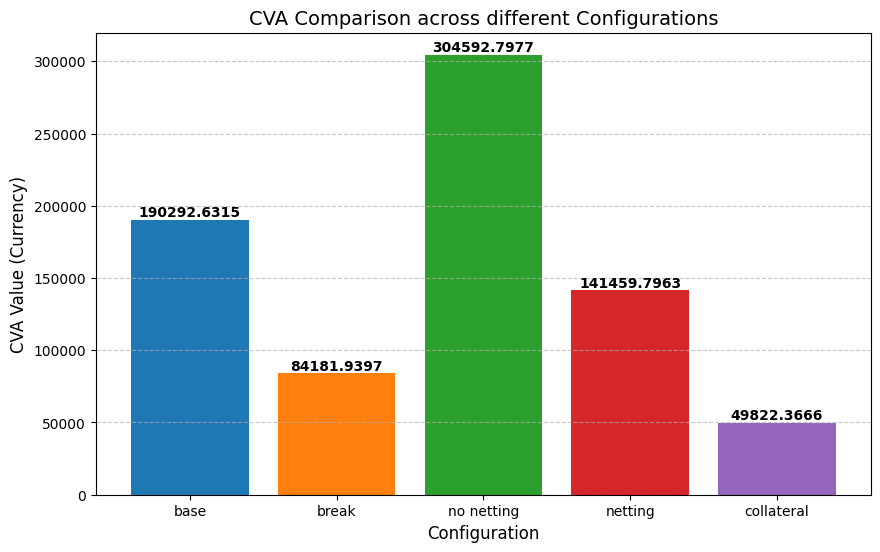

In [82]:

plt.figure(figsize=(10, 6))
bars = plt.bar(CVA_results.index, CVA_results.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

plt.title('CVA Comparison across different Configurations', fontsize=14)
plt.ylabel('CVA Value (Currency)', fontsize=12)
plt.xlabel('Configuration', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', 
             va='bottom', ha='center', fontweight='bold')

plt.show()

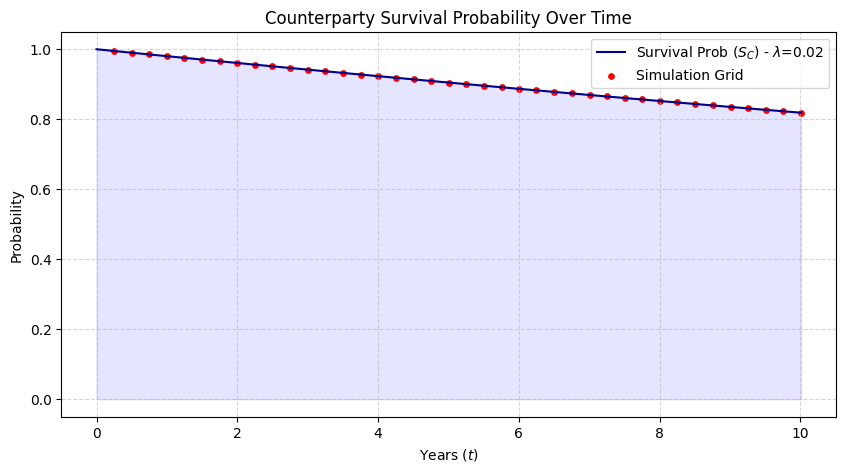

In [83]:
# Generate a continuous curve for smoothness
t_cont = np.linspace(0, times[-1], 100)
s_prob = np.exp(-hazard_rate * t_cont)

plt.figure(figsize=(10, 5))
plt.plot(
    t_cont, s_prob,
    color='darkblue',
    label=rf'Survival Prob ($S_C$) - $\lambda$={hazard_rate}'
)
plt.fill_between(t_cont, s_prob, alpha=0.1, color='blue')

# Mark the discrete simulation dates
plt.scatter(times, np.exp(-hazard_rate * times), color='red', s=15, label='Simulation Grid')

plt.title('Counterparty Survival Probability Over Time')
plt.xlabel('Years ($t$)')
plt.ylabel('Probability')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# SENSITIVITY MEASURES

In [84]:

EPE_base = expected_positive_exposure['base']

# 1) Increase lambda by 10 bps
hazard_rate_sensitivity = hazard_rate + 1e-3
exp_terms_sensitivity = np.exp(-hazard_rate_sensitivity * times)
exp_terms_with_zero_sensitivity = np.insert(exp_terms_sensitivity, 0, 1.0)
delta_integral_sensitivity = - (exp_terms_with_zero_sensitivity[1:] - exp_terms_with_zero_sensitivity[:-1])


cva_sensitivity_lambda = lgd * np.sum(
    EPE_base.values * CVA_discount_factors * delta_integral_sensitivity
)


# 2) Increase LGD by 10% 
lgd_sensitivity = lgd*(1.1)


cva_sensitivity_lgd = lgd_sensitivity * np.sum(
    EPE_base.values * CVA_discount_factors * delta_integral
)

print(f"CVA Base original: {CVA_results['base']:.4f}")
print(f"CVA with Hazard Rate +10bps: {cva_sensitivity_lambda:.4f}")
print(f"Delta CVA: {cva_sensitivity_lambda - CVA_results['base']:.4f}")
print(f"CVA with LGD +10%: {cva_sensitivity_lgd:.4f}")
print(f"Delta CVA: {cva_sensitivity_lgd - CVA_results['base']:.4f}")

CVA Base original: 190292.6315
CVA with Hazard Rate +10bps: 199009.6443
Delta CVA: 8717.0128
CVA with LGD +10%: 209321.8946
Delta CVA: 19029.2631


In [85]:
# 3) delta bucket : bump 1bp 0-5y
dates_depos_futures_swaps = pd.concat([
        pd.Series(df_depos.index),
        pd.Series(df_futures.index),
        pd.Series(df_swaps.index)
    ]).unique()

dates_depos_futures_swaps = sorted(pd.to_datetime(dates_depos_futures_swaps))

date_5y = business_date_offset(settlement_date, year_offset=5)
bump_0_5y = pd.Series(0.0, index= dates_depos_futures_swaps)
bump_0_5y[bump_0_5y.index <= date_5y] = 0.0001


bumped_0_5y_dfs, _, _ = bootstrap(settlement_date, df_depos, df_futures, df_swaps, depo_idx=[0, 3], fut_idx=[0, 7], shock=bump_0_5y)

prev_date = settlement_date
expected_positive_exposure_0_5y = pd.DataFrame(
    data=0.0, index=simulation_grid, columns=["base"])

for i, sim_date in enumerate(simulation_grid):

    expiry_idx1 = list(simulation_grid[i:]).index(expiry) if expiry in simulation_grid[i:] else None

    dt = year_frac_act_x(prev_date, sim_date, 365)

    x_t = x_paths[:, i]                                          # shape (n_sim,)

    A, C = affine_trick(sim_date, simulation_grid[i:], mean_reversion, sigma, bumped_0_5y_dfs)

    discount_factors_hw = (
        A.values[np.newaxis, :]
        * np.exp(-C.values[np.newaxis, :] * x_t[:, np.newaxis])
    )                                                             # shape (n_sim, n_grid)

    fixed_leg_1 = (
        irs_cash_flows_extended.values[np.newaxis, i:] * discount_factors_hw
    ).sum(axis=1)                                                 # shape (n_sim,)

    if expiry_idx1 is not None:
        float_leg_1 = 1.0 - discount_factors_hw[:, expiry_idx1]
        MtF_1 = notional * (float_leg_1 - fixed_leg_1)
    else:
        MtF_1 = np.zeros(simulations_num)   # swap 1 expired


    MtF_base = MtF_1

    MtF_pos_base     = np.maximum(MtF_base,     0.0)
    MtF_pos_1        = np.maximum(MtF_1,        0.0)   # standalone swap 1
    expected_positive_exposure_0_5y.loc[sim_date, "base"]       = MtF_pos_base.mean()

    prev_date = sim_date

CVA_discount_factors_0_5y = np.array([
    get_discount_factor_by_zero_rates_linear_interp(
        settlement_date, d, bumped_0_5y_dfs.index, bumped_0_5y_dfs.values
    ) for d in expected_positive_exposure_0_5y.index
])

cva_sensitivity_0_5y = lgd * np.sum(
    expected_positive_exposure_0_5y['base'].values * CVA_discount_factors_0_5y * delta_integral
)


print(f"CVA Base original: {CVA_results['base']:.4f}")
print(f"CVA - bump bucket 0-5y: {cva_sensitivity_0_5y:.4f}")
print(f"Delta CVA: {cva_sensitivity_0_5y - CVA_results['base']:.4f}")

CVA Base original: 190292.6315
CVA - bump bucket 0-5y: 189581.0327
Delta CVA: -711.5988


In [86]:
# 4) delta bucket : +1bp 5-10 years 

date_10y = business_date_offset(settlement_date, year_offset=10)

bump_5_10y = pd.Series(0.0, index=dates_depos_futures_swaps)
bump_5_10y[(bump_5_10y.index > date_5y) & (bump_5_10y.index <= date_10y)] = 0.0001


bumped_5_10y_dfs, _, _ = bootstrap(settlement_date, df_depos, df_futures, df_swaps, depo_idx=[0, 3], fut_idx=[0, 7], shock=bump_5_10y)


prev_date = settlement_date

expected_positive_exposure_5_10y = pd.DataFrame(
    data=0.0, index=simulation_grid, columns=["base"])

for i, sim_date in enumerate(simulation_grid):

    expiry_idx1 = list(simulation_grid[i:]).index(expiry) if expiry in simulation_grid[i:] else None

    dt = year_frac_act_x(prev_date, sim_date, 365)

    x_t = x_paths[:, i]                                          # shape (n_sim,)

    A, C = affine_trick(sim_date, simulation_grid[i:], mean_reversion, sigma, bumped_5_10y_dfs)

    discount_factors_hw = (
        A.values[np.newaxis, :]
        * np.exp(-C.values[np.newaxis, :] * x_t[:, np.newaxis])
    )                                                             # shape (n_sim, n_grid)

    fixed_leg_1 = (
        irs_cash_flows_extended.values[np.newaxis, i:] * discount_factors_hw
    ).sum(axis=1)                                                 # shape (n_sim,)

    if expiry_idx1 is not None:
        float_leg_1 = 1.0 - discount_factors_hw[:, expiry_idx1]
        MtF_1 = notional * (float_leg_1 - fixed_leg_1)
    else:
        MtF_1 = np.zeros(simulations_num)   # swap 1 expired


    MtF_base = MtF_1

    MtF_pos_base     = np.maximum(MtF_base,     0.0)
    MtF_pos_1        = np.maximum(MtF_1,        0.0)   # standalone swap 1
    expected_positive_exposure_5_10y.loc[sim_date, "base"]       = MtF_pos_base.mean()

    prev_date = sim_date

cva_sensitivity_5_10y = lgd * np.sum(
    expected_positive_exposure_5_10y['base'].values * CVA_discount_factors * delta_integral
)

print(f"CVA Base original: {CVA_results['base']:.4f}")
print(f"CVA - bucket 5-10y: {cva_sensitivity_5_10y:.4f}")
print(f"Delta CVA: {cva_sensitivity_5_10y - CVA_results['base']:.4f}")

CVA Base original: 190292.6315
CVA - bucket 5-10y: 192615.3203
Delta CVA: 2322.6888


In [87]:
# 5) Increase sigma by 1 bp
mean_reversion = 0.0205
sigma_sensitivity = 0.0094 + 1e-4

x_paths_sensitivity = simulate_ou_process(simulation_grid,
                              settlement_date, 
                              mean_reversion, 
                              sigma_sensitivity, 
                              simulations_num,
                              x0=0)

In [88]:
prev_date = settlement_date
expected_positive_exposure_sigma = pd.DataFrame(
    data=0.0, index=simulation_grid, columns=["base"])

for i, sim_date in enumerate(simulation_grid):

    expiry_idx1 = list(simulation_grid[i:]).index(expiry) if expiry in simulation_grid[i:] else None

    dt = year_frac_act_x(prev_date, sim_date, 365)

    x_t = x_paths_sensitivity[:, i]                                          # shape (n_sim,)

    A, C = affine_trick(sim_date, simulation_grid[i:], mean_reversion, sigma, discount_factors)

    discount_factors_hw = (
        A.values[np.newaxis, :]
        * np.exp(-C.values[np.newaxis, :] * x_t[:, np.newaxis])
    )                                                             # shape (n_sim, n_grid)

    fixed_leg_1 = (
        irs_cash_flows_extended.values[np.newaxis, i:] * discount_factors_hw
    ).sum(axis=1)                                                 # shape (n_sim,)

    if expiry_idx1 is not None:
        float_leg_1 = 1.0 - discount_factors_hw[:, expiry_idx1]
        MtF_1 = notional * (float_leg_1 - fixed_leg_1)
    else:
        MtF_1 = np.zeros(simulations_num)   # swap 1 expired


    MtF_base = MtF_1

    MtF_pos_base     = np.maximum(MtF_base,     0.0)
    MtF_pos_1        = np.maximum(MtF_1,        0.0)   # standalone swap 1
    expected_positive_exposure_sigma.loc[sim_date, "base"]       = MtF_pos_base.mean()

    prev_date = sim_date

In [89]:
cva_sensitivity_sigma = lgd * np.sum(
    expected_positive_exposure_sigma['base'].values * CVA_discount_factors * delta_integral
)

print(f"CVA Base original: {CVA_results['base']:.4f}")
print(f"CVA with sigma + 1bp: {cva_sensitivity_sigma:.4f}")
print(f"Delta CVA: {cva_sensitivity_sigma - CVA_results['base']:.4f}")

CVA Base original: 190292.6315
CVA with sigma + 1bp: 192270.0659
Delta CVA: 1977.4344


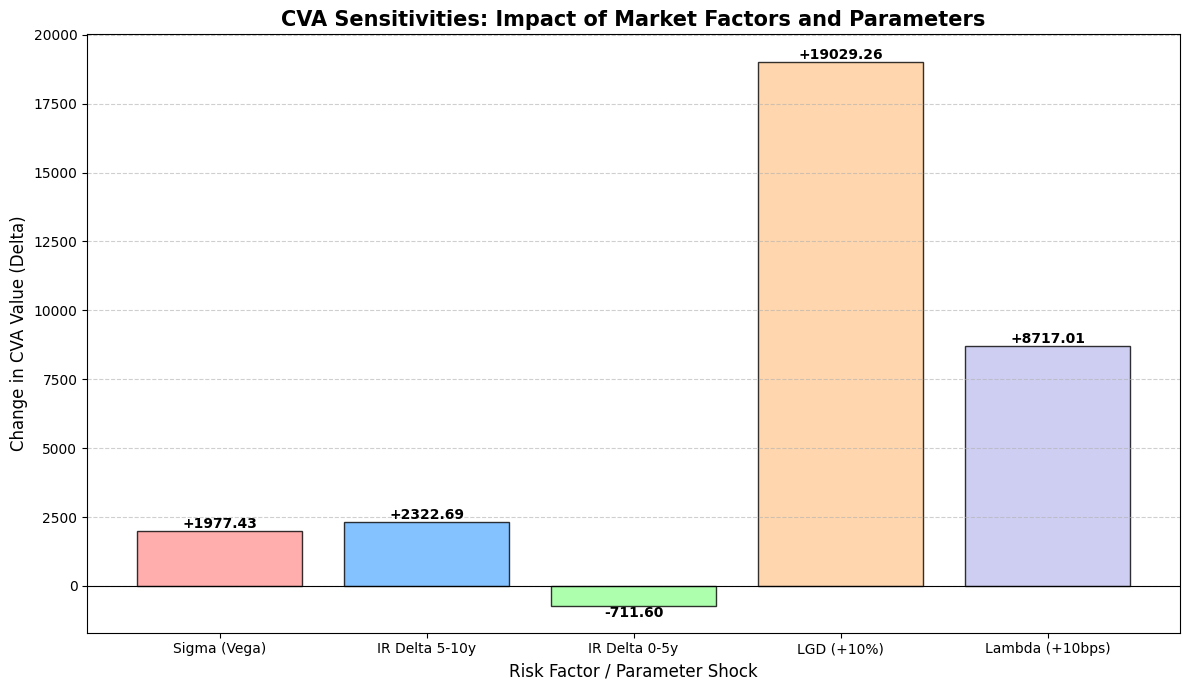

In [90]:
sensitivity_data = {
    'Sigma (Vega)': cva_sensitivity_sigma - CVA_results['base'],
    'IR Delta 5-10y': cva_sensitivity_5_10y - CVA_results['base'],
    'IR Delta 0-5y': cva_sensitivity_0_5y - CVA_results['base'],
    'LGD (+10%)': cva_sensitivity_lgd - CVA_results['base'],
    'Lambda (+10bps)': cva_sensitivity_lambda - CVA_results['base']
}

# 2. Convert to a Series for easy plotting
cva_impacts = pd.Series(sensitivity_data)

# 3. Create the Bar Plot
plt.figure(figsize=(12, 7))
# Use colors to distinguish between credit, market, and model parameters
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']
bars = plt.bar(cva_impacts.index, cva_impacts.values, color=colors, edgecolor='black', alpha=0.8)

# 4. Formatting the chart
plt.axhline(0, color='black', linewidth=0.8) # Reference line at zero
plt.title('CVA Sensitivities: Impact of Market Factors and Parameters', fontsize=15, fontweight='bold')
plt.ylabel('Change in CVA Value (Delta)', fontsize=12)
plt.xlabel('Risk Factor / Parameter Shock', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 5. Add data labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:+.2f}', 
             va='bottom' if yval > 0 else 'top', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()